In [2]:
import duckdb
import pandas as pd

con = duckdb.connect(r"..\data\BaseDeDatos_Working.db")

In [3]:
df = con.execute("""
SELECT *
FROM incendios
""").df()

In [4]:
df.columns

Index(['id_clave_inc', 'id_cvegeo', 'id_causa', 'id_vegetacion', 'latitud',
       'longitud', 'fecha_inicio', 'tipo_de_incendio', 'anio'],
      dtype='str')

In [5]:
ignicion_vars = [
    "id_causa",
    "poblacion",  # si existe en demografia
    "densidad",   # ejemplo
]

propagacion_vars = [
    "NDVI",
    "NDWI",
    "NDMI",
    "TSOIL6",
    "T10M_RANGE",
    "TS_RANGE",
    "EVLAND",
    "EVPTRNS",
    "CLRSKY_SFC_LW_DWN",
    "ALLSKY_SFC_LW_UP"
]

impacto_vars = [
    "danos",
    "tipo_de_vegetacion",
    "regimen_del_fuego"
]

In [6]:
con.execute("SELECT * FROM climatologia LIMIT 5").df()

,id_registro,id_variable,id_clave_inc,fecha_de_observacion,resultado_numerico
0,491551,SRF_ALB_ADJ,17-15-0771,2017-03-24,0.13
1,491552,SRF_ALB_ADJ,17-15-0771,2017-03-25,0.14
2,491553,SRF_ALB_ADJ,17-15-0771,2017-03-26,0.12
3,491554,SRF_ALB_ADJ,17-15-0771,2017-03-27,0.15
4,491555,SRF_ALB_ADJ,17-15-0771,2017-03-28,0.14


In [7]:
con.execute("SELECT * FROM demografia LIMIT 5").df()

,id_cvegeo,anio,sexo,pob_total,r_00_04,r_05_09,r_10_14,r_15_19,r_20_24,r_25_29,...,r_40_44,r_45_49,r_50_54,r_55_59,r_60_64,r_65_69,r_70_74,r_75_79,r_80_84,r_85_mm
0,15001,2019,hombres,33228,3617,3521,3672,3401,2949,2616,...,1722,1649,1460,1214,964,758,612,446,278,247
1,15002,2015,hombres,77323,7796,7663,7956,7497,7017,6414,...,5533,4504,3533,2717,1886,1250,877,595,359,295
2,15002,2018,hombres,83837,6731,7318,7967,8159,8023,7703,...,5905,5363,4334,3308,2300,1504,1062,691,399,341
3,15002,2021,mujeres,88986,5957,6694,7813,8329,7987,7714,...,6964,6503,5243,3942,2914,1990,1317,855,496,447
4,15003,2019,hombres,24597,2416,2466,2586,2488,2274,2084,...,1347,1211,1050,915,755,569,418,288,208,179


In [8]:
con.execute("SELECT * FROM vegetacion LIMIT 5").df()

,id_vegetacion,regimen_del_fuego,tipo_de_vegetacion
0,18,otros,mezquital espinoso
1,19,otros,matorral crasicaule
2,20,adaptado,matorral espinoso tamaulipeco
3,21,adaptado,pradera de alta montana
4,22,otros,matorral sarco-crasicaule


In [9]:
df.head()

,id_clave_inc,id_cvegeo,id_causa,id_vegetacion,latitud,longitud,fecha_inicio,tipo_de_incendio,anio
0,15-15-0156,15039,32,28,19.309111,-99.788834,2015-03-02,superficial,2015
1,16-15-0018,15014,30,1,19.877222,-99.875557,2016-01-23,superficial,2016
2,16-15-0153,15060,30,27,19.596666,-99.432281,2016-02-11,superficial,2016
3,16-15-0207,15063,39,1,19.002361,-99.367722,2016-02-16,superficial,2016
4,16-15-0869,15038,30,27,19.574194,-99.395164,2016-04-08,superficial,2016


In [10]:
df = con.execute("""
SELECT 
    id_clave_inc,
    id_variable,
    AVG(resultado_numerico) AS valor
FROM climatologia
GROUP BY id_clave_inc, id_variable
""").df()

df_pivot = df.pivot(
    index="id_clave_inc",
    columns="id_variable",
    values="valor"
).reset_index()

print(df_pivot.shape)
df_pivot.head()

(12586, 123)


id_variable,id_clave_inc,AIRMASS,ALLSKY_KT,ALLSKY_NKT,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_LW_UP,ALLSKY_SFC_PAR_DIFF,ALLSKY_SFC_PAR_DIRH,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DIFF,...,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE,WS50M,WS50M_MAX,WS50M_MIN,WS50M_RANGE,Z0M
0,15-15-0001,3.328,0.654,0.809,23.897,31.743,3.458,4.118,7.576,5.758,...,2.882,1.158,2.180,0.338,1.842,2.616,4.897,0.952,3.945,0.424
1,15-15-0002,3.420,0.638,0.796,24.189,31.832,3.784,3.589,7.377,6.397,...,2.736,1.269,2.440,0.418,2.022,2.797,4.303,0.983,3.320,0.203
2,15-15-0003,3.783,0.657,0.838,24.237,32.195,3.557,4.054,7.614,5.969,...,2.100,0.668,1.322,0.104,1.218,1.884,3.334,0.355,2.979,0.985
3,15-15-0004,3.783,0.657,0.838,24.237,32.195,3.557,4.054,7.614,5.969,...,2.442,1.294,2.369,0.521,1.848,2.968,4.445,1.208,3.237,0.180
4,15-15-0005,3.959,0.661,0.854,24.284,32.246,3.656,4.031,7.691,6.157,...,2.390,0.882,1.828,0.182,1.646,2.095,3.810,0.563,3.247,0.420


In [11]:
df_pivot = df_pivot.rename(columns={"id_clave_inc": "id_clave_inc"})

In [12]:
df_incendios = con.execute("SELECT * FROM incendios").df()

In [13]:
df_final = df_incendios.merge(df_pivot, on="id_clave_inc", how="left")

In [14]:
df_final.columns

Index(['id_clave_inc', 'id_cvegeo', 'id_causa', 'id_vegetacion', 'latitud',
       'longitud', 'fecha_inicio', 'tipo_de_incendio', 'anio', 'AIRMASS',
       ...
       'WS10M_RANGE', 'WS2M', 'WS2M_MAX', 'WS2M_MIN', 'WS2M_RANGE', 'WS50M',
       'WS50M_MAX', 'WS50M_MIN', 'WS50M_RANGE', 'Z0M'],
      dtype='str', length=131)

In [15]:
df_final.shape

(12703, 131)

In [16]:
df_final.isna().sum().sort_values(ascending=False).head(20)

CLRSKY_NKT    1974
PBLTOP        1942
TSOIL2        1942
T10M_RANGE    1942
TO3           1942
TQV           1942
TSOIL5        1942
TSOIL6        1942
TSOIL3        1942
TSOIL4        1942
TS_RANGE      1942
V50M          1942
U2M           1942
V2M           1942
U50M          1942
Z0M           1942
TSURF         1942
TS_ADJ        1942
TROPPB        1942
RHOA          1942
dtype: int64

In [17]:
df_final["indice_propagacion"] = (
    df_final["NDVI"].fillna(0) * 0.4 -
    df_final["NDMI"].fillna(0) * 0.3 -
    df_final["NDWI"].fillna(0) * 0.2 +
    df_final["TSOIL6"].fillna(df_final["TSOIL6"].median()) * 0.1
)

## Analisis por tipo de incendio 

In [18]:
df_final.groupby("tipo_de_incendio")["indice_propagacion"].mean().sort_values()

tipo_de_incendio
superficial    1.723080
mixto          1.734318
de copa        1.743945
subterraneo    1.785958
Name: indice_propagacion, dtype: float64

El índice de propagación muestra un incremento progresivo conforme aumenta la complejidad del incendio (superficial < mixto < copa < subterráneo), lo que refleja que los eventos más críticos están vinculados a una menor humedad del combustible y una mayor carga energética. Sin embargo, dado que el rango de variación es estrecho (1.723 a 1.785), se concluye que, aunque el índice es capaz de discriminar tendencias generales de severidad y disponibilidad biomasa, no debe utilizarse como un criterio único para separar los tipos de incendio, sino como un indicador de condiciones ambientales críticas.

## Analisis por causa del incendio

In [19]:
df_final.groupby("id_causa")["indice_propagacion"].mean()

id_causa
1     1.716506
2     1.768435
3     1.848857
4     1.638215
5     1.687878
6     1.632399
7     1.754335
8     1.720058
9     1.761067
10    1.816461
11    1.878980
12    1.885605
13    1.758692
14    1.656039
15    1.692810
16    1.785957
17    1.981733
18    1.667855
19    1.725910
20    1.746047
21    1.767109
22    1.805770
23    1.710946
24    1.780250
25    1.778876
26    1.712046
27    1.736706
28    1.745597
29    1.800454
30    1.721207
31    1.674126
32    1.759896
33    1.670395
34    1.605551
35    1.677095
36    1.872205
37    1.681546
38    1.652822
39    1.723897
40    1.694693
41    1.820825
42    1.590396
43    1.606738
44    1.723072
45    1.675576
46    1.669704
47    1.581854
48    1.857399
49    1.604416
50    1.758730
51    1.794458
52    1.692635
53    1.707907
54    1.730593
55    1.627849
56    1.903749
57    1.721947
58    1.672135
Name: indice_propagacion, dtype: float64

El análisis del índice de propagación por causa revela una variación significativa (entre 1.63 y 1.98), lo que demuestra que el comportamiento del fuego no es uniforme y depende de la interacción entre el origen del incendio y el entorno. Los resultados sugieren que ciertas causas (como las identificadas con índices superiores a 1.85) están asociadas a escenarios climáticos más críticos de baja humedad y alta disponibilidad de combustible seco, mientras que las causas con índices menores ocurren en condiciones menos extremas. En conclusión, el hallazgo principal es que la causa no determina por sí sola la intensidad del fuego, sino que actúa como un detonante que se potencia según el estado de la vegetación y el clima al momento del evento.

## Analisis por año 

In [20]:
df_final.groupby("anio")["indice_propagacion"].mean()

anio
2015    1.710269
2016    1.676701
2017    1.717903
2018    1.707777
2019    1.716475
2020    1.752080
2021    1.741632
2022    1.778391
2023    1.767791
2024    1.699567
2025    1.702912
Name: indice_propagacion, dtype: float64

El análisis histórico revela una tendencia incremental en el índice de propagación durante el periodo 2016–2023, alcanzando su fase más crítica entre 2020 y 2023, años caracterizados por un mayor riesgo ecológico debido al estrés hídrico y la acumulación de energía térmica. Esta progresión sugiere un deterioro de las condiciones ambientales que favorece la severidad de los incendios, seguida de un ligero descenso en el bienio 2024–2025 que podría atribuirse a la variabilidad climática interanual o a una recuperación ambiental parcial. En conclusión, el sistema muestra una evolución desde condiciones de equilibrio hacia escenarios de mayor vulnerabilidad climática, consolidando al periodo reciente como el de mayor complejidad para la gestión del fuego.

## Mapa de hotspots de incendios 

In [21]:
df_final[["latitud", "longitud", "indice_propagacion"]].head()

,latitud,longitud,indice_propagacion
0,19.309111,-99.788834,1.715070
1,19.877222,-99.875557,1.774486
2,19.596666,-99.432281,1.369911
3,19.002361,-99.367722,1.673714
4,19.574194,-99.395164,1.485263


In [22]:
df_map = df_final.dropna(subset=["latitud", "longitud", "indice_propagacion"])

In [23]:
import folium
from folium.plugins import HeatMap

df_map = df_final.dropna(subset=["latitud", "longitud", "indice_propagacion"])

df_map["peso"] = (
    df_map["indice_propagacion"] - df_map["indice_propagacion"].min()
) / (
    df_map["indice_propagacion"].max() - df_map["indice_propagacion"].min()
)

map_center = [19.0433, -98.1989]

m = folium.Map(location=map_center, zoom_start=7)

heat_data = df_map[["latitud", "longitud", "peso"]].values.tolist()

HeatMap(heat_data, radius=10, blur=15).add_to(m)

m.save("heatmap_incendios.html")

In [24]:
df_hot = df_map[df_map["indice_propagacion"] > df_map["indice_propagacion"].quantile(0.90)]

In [25]:
m2 = folium.Map(location=map_center, zoom_start=7)

HeatMap(df_hot[["latitud", "longitud", "indice_propagacion"]].values.tolist(),
        radius=15, blur=20).add_to(m2)

m2.save("heatmap_incendios_hot.html")

El análisis espacial mediante mapas de calor permitió identificar zonas con alta concentración del índice de propagación, lo que sugiere la existencia de hotspots de incendios forestales. Estas áreas representan regiones donde la combinación de condiciones climáticas y vegetación favorece la rápida expansión del fuego.

## Clustering de hotspots con K-Means geográfico

In [26]:
df_cluster = df_final.dropna(subset=["latitud", "longitud"])

In [27]:
X = df_cluster[["latitud", "longitud"]]

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X)

In [29]:
import folium

map_center = [19.0433, -98.1989]
m = folium.Map(location=map_center, zoom_start=7)

colors = ["red", "blue", "green", "purple", "orange"]

for _, row in df_cluster.iterrows():
    folium.CircleMarker(
        location=[row["latitud"], row["longitud"]],
        radius=3,
        color=colors[row["cluster"] % len(colors)],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m.save("clusters_incendios.html")

In [30]:
df_cluster.groupby("cluster")["indice_propagacion"].mean()

cluster
0    1.662810
1    1.807320
2    1.587966
3    1.813608
4    1.695005
Name: indice_propagacion, dtype: float64

In [31]:
df_cluster["cluster"].value_counts()

cluster
1    3595
2    2548
3    2510
4    2009
0    1924
Name: count, dtype: int64

El análisis de clustering espacial mediante K-Means permitió identificar regiones homogéneas de ocurrencia de incendios forestales. Cada cluster representa una zona con patrones similares de localización, lo que sugiere la existencia de regiones de riesgo diferenciadas dentro del territorio analizado.

In [32]:
df_cluster.groupby("cluster")["indice_propagacion"].mean().sort_values()

cluster
2    1.587966
0    1.662810
4    1.695005
1    1.807320
3    1.813608
Name: indice_propagacion, dtype: float64

In [33]:
cluster_riesgo = {
    2: "Bajo",
    0: "Medio-Bajo",
    4: "Medio",
    1: "Alto",
    3: "Crítico"
}

In [34]:
df_cluster["zona_riesgo"] = df_cluster["cluster"].map(cluster_riesgo)

In [35]:
df_cluster.groupby("zona_riesgo")["indice_propagacion"].mean()

zona_riesgo
Alto          1.807320
Bajo          1.587966
Crítico       1.813608
Medio         1.695005
Medio-Bajo    1.662810
Name: indice_propagacion, dtype: float64

In [36]:
import folium

map_center = [19.0433, -98.1989]
m = folium.Map(location=map_center, zoom_start=7)

color_dict = {
    "Bajo": "green",
    "Medio-Bajo": "lightgreen",
    "Medio": "orange",
    "Alto": "red",
    "Crítico": "darkred"
}

for _, row in df_cluster.iterrows():
    folium.CircleMarker(
        location=[row["latitud"], row["longitud"]],
        radius=3,
        color=color_dict[row["zona_riesgo"]],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m.save("zonas_riesgo_incendios.html")

<div class="alert alert-block alert-danger">
<b>ZONA CRÍTICA (cluster 3)</b>
mayor índice (~1.81), condiciones más secas, alta probabilidad de propagación rápida, prioridad máxima de atención
</div>
<div class="alert alert-block alert-danger">
<b>ZONA ALTA (cluster 1)</b>
índice muy alto (~1.80), incendios intensos probables, condiciones climáticas adversas
</div>
<div class="alert alert-block alert-warning">
<b> ZONA MEDIA (cluster 4) </b> condiciones intermedias, propagación moderada
</div>
<div class="alert alert-block alert-success">
<b> ZONA MEDIA-BAJA (cluster 0)</b> menor riesgo relativo, condiciones parcialmente favorables
</div>
<div class="alert alert-block alert-success">
<b> ZONA BAJA (cluster 2) </b> menor propagación (~1.58), mayor humedad o menor combustible
</div>

In [37]:
df_cluster["cluster"].value_counts()

cluster
1    3595
2    2548
3    2510
4    2009
0    1924
Name: count, dtype: int64

In [38]:
cluster_riesgo = {
    3: "Crítico",        # alto índice
    1: "Alto (prioridad)",  # alto índice + alta frecuencia
    4: "Medio",
    0: "Bajo",
    2: "Bajo (frecuente)"
}

## Validacion de indice critico

In [39]:
df_final[["indice_propagacion", "NDVI", "NDMI", "NDWI", "TSOIL6"]].corr()

,indice_propagacion,NDVI,NDMI,NDWI,TSOIL6
indice_propagacion,1.000000,0.344085,-0.065829,-0.186441,0.894494
NDVI,0.344085,1.000000,0.564755,0.361680,0.126132
NDMI,-0.065829,0.564755,1.000000,0.928773,0.147729
NDWI,-0.186441,0.361680,0.928773,1.000000,0.101133
TSOIL6,0.894494,0.126132,0.147729,0.101133,1.000000


El análisis de correlación muestra que la temperatura del suelo (TSOIL6) es el principal factor asociado al índice de propagación, lo que indica que las condiciones térmicas juegan un papel dominante en la dinámica del fuego. Por otro lado, la vegetación (NDVI) presenta una relación positiva moderada, sugiriendo que la disponibilidad de combustible influye en la propagación. Las variables de humedad (NDMI y NDWI) muestran una relación negativa débil, posiblemente debido a la alta correlación entre ellas y a la predominancia de la temperatura en el sistema analizado.

<Axes: xlabel='tipo_de_incendio', ylabel='indice_propagacion'>

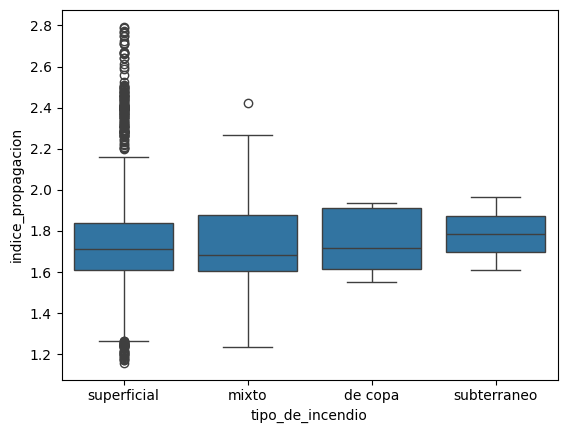

In [40]:
import seaborn as sns
sns.boxplot(data=df_final, x="tipo_de_incendio", y="indice_propagacion")

## Analisis de vegetacion


In [41]:
df_final.groupby("id_vegetacion")["indice_propagacion"].mean().sort_values()

id_vegetacion
24    1.499400
19    1.593780
39    1.615910
8     1.616696
6     1.619600
30    1.619600
36    1.619600
2     1.619600
38    1.619600
22    1.630998
23    1.635033
5     1.645739
26    1.647872
16    1.675858
7     1.683691
41    1.683933
33    1.690312
25    1.710251
1     1.713688
13    1.714727
17    1.723281
27    1.728340
10    1.730016
11    1.734251
40    1.734913
28    1.751049
3     1.755977
31    1.773345
34    1.780605
35    1.786626
12    1.792675
21    1.796378
20    1.823530
18    1.837070
9     1.841488
4     1.843024
29    1.848049
37    1.854337
32    1.907028
14    1.973858
15    2.708239
Name: indice_propagacion, dtype: float64

In [42]:
df_final["id_vegetacion"].value_counts()

id_vegetacion
1     3796
28    2491
27    1578
25     887
7      755
11     666
13     635
10     578
40     256
19     253
33     172
29     166
2       82
41      66
14      62
35      52
5       45
32      35
12      27
24      13
36      13
16      12
21       9
3        9
34       6
23       6
17       5
30       4
39       4
38       4
26       3
37       2
6        2
4        2
9        1
20       1
22       1
18       1
31       1
8        1
15       1
Name: count, dtype: int64

In [43]:
df_final["veg_riesgo"] = pd.qcut(
    df_final["indice_propagacion"],
    3,
    labels=["bajo", "medio", "alto"]
)

In [44]:
df_final = df_final.dropna(subset=["TSOIL6", "NDVI"])

In [45]:
df_final.groupby("id_vegetacion")[["TSOIL6", "NDVI", "indice_propagacion"]].mean()

,TSOIL6,NDVI,indice_propagacion
id_vegetacion,,,
1,16.513701,0.453522,1.713961
3,18.507501,0.440897,1.940418
4,18.333000,0.432639,1.992733
5,15.008038,0.244733,1.593297
7,16.273287,0.477942,1.683691
8,14.770000,0.243396,1.616696
9,17.772001,0.758403,1.841488
10,16.635470,0.415136,1.759723
11,17.050385,0.502584,1.791618


In [46]:
df_final[df_final["id_vegetacion"] == 15].shape

(1, 133)

In [47]:
df_final["tipo_combustible"] = pd.qcut(
    df_final["NDVI"],
    3,
    labels=["bajo", "medio", "alto"]
)

In [48]:
df_final.groupby("tipo_combustible")["indice_propagacion"].mean()

tipo_combustible
bajo     1.650148
medio    1.767744
alto     1.766775
Name: indice_propagacion, dtype: float64

La propagación del fuego está principalmente determinada por la temperatura del suelo, la cual actúa como factor detonante, mientras que la vegetación define la cantidad de combustible disponible. La combinación de altas temperaturas y cobertura vegetal intermedia o alta genera las condiciones más favorables para incendios de alta intensidad.

## Clima mas vegetacion 

In [49]:
df_final.groupby("id_vegetacion")[["TSOIL6", "NDMI", "NDVI", "indice_propagacion"]].mean()

,TSOIL6,NDMI,NDVI,indice_propagacion
id_vegetacion,,,,
1,16.513701,0.342255,0.453522,1.713961
3,18.507501,0.282629,0.440897,1.940418
4,18.333000,0.151614,0.432639,1.992733
5,15.008038,0.076620,0.244733,1.593297
7,16.273287,0.373131,0.477942,1.683691
8,14.770000,-0.008277,0.243396,1.616696
9,17.772001,0.641176,0.758403,1.841488
10,16.635470,0.238388,0.415136,1.759723
11,17.050385,0.336339,0.502584,1.791618


La propagación del fuego está determinada por la interacción entre la temperatura del suelo, la disponibilidad de combustible vegetal y la humedad, donde la temperatura actúa como factor dominante y la humedad como modulador del proceso.

- SI temperatura alta:
    humedad decide intensidad

- SI temperatura baja:
    no importa la vegetación → fuego bajo

## Analisis espacial 

In [50]:
df_cluster.groupby("zona_riesgo").size()

zona_riesgo
Alto          3595
Bajo          2548
Crítico       2510
Medio         2009
Medio-Bajo    1924
dtype: int64

In [51]:
df_cluster.groupby("cluster")[["latitud", "longitud"]].mean()

,latitud,longitud
cluster,,
0,19.303835,-98.741127
1,19.186508,-100.075516
2,19.586067,-99.396660
3,19.039038,-99.546722
4,19.832775,-99.931038


In [52]:
df_cluster.groupby("zona_riesgo")[["latitud","longitud"]].mean()

,latitud,longitud
zona_riesgo,,
Alto,19.186508,-100.075516
Bajo,19.586067,-99.396660
Crítico,19.039038,-99.546722
Medio,19.832775,-99.931038
Medio-Bajo,19.303835,-98.741127


El análisis espacial permitió identificar zonas con diferentes niveles de riesgo, donde algunas regiones presentan una alta frecuencia de incendios pero baja capacidad de propagación, mientras que otras combinan condiciones climáticas y de vegetación que favorecen incendios de alta intensidad. Estas diferencias espaciales evidencian la necesidad de estrategias de manejo diferenciadas según la región.

## Demografia 

In [53]:
df_demo = con.execute("SELECT * FROM demografia").df()

In [54]:
df_final = df_final.merge(df_demo, on="id_cvegeo", how="left")

In [55]:
df_final.columns

Index(['id_clave_inc', 'id_cvegeo', 'id_causa', 'id_vegetacion', 'latitud',
       'longitud', 'fecha_inicio', 'tipo_de_incendio', 'anio_x', 'AIRMASS',
       ...
       'r_40_44', 'r_45_49', 'r_50_54', 'r_55_59', 'r_60_64', 'r_65_69',
       'r_70_74', 'r_75_79', 'r_80_84', 'r_85_mm'],
      dtype='str', length=155)

In [56]:
cols_poblacion = [col for col in df_final.columns if col.startswith("r_")]

df_final["poblacion_total"] = df_final[cols_poblacion].sum(axis=1)

In [57]:
df_final["pob_joven"] = df_final[
    ["r_00_04", "r_05_09", "r_10_14"]
].sum(axis=1)

In [58]:
df_final["pob_adulta"] = df_final[
    ["r_15_19", "r_20_24", "r_25_29", "r_30_34"]
].sum(axis=1)

In [59]:
df_final["pob_mayor"] = df_final[
    ["r_60_64", "r_65_69", "r_70_74", "r_75_79", "r_80_84", "r_85_mm"]
].sum(axis=1)

In [60]:
df_final["presion_humana"] = df_final["pob_adulta"] / df_final["poblacion_total"]

In [61]:
df_final = df_final.drop(columns=cols_poblacion)

In [62]:
df_final[["poblacion_total", "indice_propagacion"]].corr()

,poblacion_total,indice_propagacion
poblacion_total,1.000000,-0.390568
indice_propagacion,-0.390568,1.000000


La densidad poblacional presenta una relación inversa con la propagación del fuego, lo que sugiere que las zonas más pobladas, aunque pueden tener mayor número de igniciones, tienden a presentar incendios menos intensos debido a la intervención humana y menor disponibilidad de combustible continuo.

# FEATURE ENGINEERING

In [63]:
df_final["mes"] = df_final["fecha_inicio"].dt.month
df_final["estacion"] = df_final["mes"] % 12 // 3 + 1

In [64]:
df_final["temp_combustible"] = df_final["TSOIL6"] * df_final["NDVI"]

In [65]:
df_final["estres_hidrico"] = df_final["TSOIL6"] - df_final["NDMI"]

In [66]:
df_final["riesgo"] = pd.qcut(
    df_final["indice_propagacion"],
    3,
    labels=["bajo", "medio", "alto"]
)

In [67]:
df_final = pd.get_dummies(
    df_final,
    columns=["tipo_de_incendio"],
    drop_first=True
)

In [68]:
df_model = df_final.drop(columns=[
    "id_clave_inc",
    "fecha_inicio"
])

In [69]:
df_model["presion_humana"] = df_final["pob_adulta"] / df_final["poblacion_total"]

In [70]:
df_model = df_model.dropna()

In [71]:
df_model[["NDMI", "NDWI"]].corr()

,NDMI,NDWI
NDMI,1.000000,0.927193
NDWI,0.927193,1.000000


In [72]:
df_model = df_model.drop(columns=["NDWI"])

Se identificó una alta correlación entre los índices NDMI y NDWI (r = 0.92), lo que indica redundancia en la información de humedad. Por ello, se decidió conservar únicamente NDMI para evitar multicolinealidad en el modelo.

# DATA SET FINAL

In [73]:
clima_vars = [
    "TSOIL6",   #  dominante
    "NDVI",     #  vegetación
    "NDMI"      #  humedad
]

In [74]:
extras_clima = [
    "EVPTRNS",       # evapotranspiración
    "T2M",           # temperatura aire
    "T10M_RANGE"     # variabilidad térmica
]

In [75]:
cols_poblacion = [col for col in df_final.columns if col.startswith("r_")]

df_model["poblacion_total"] = df_final[cols_poblacion].sum(axis=1)

In [76]:
cols_finales = [
    #  clima
    "TSOIL6", "NDVI", "NDMI","EVPTRNS", "T2M", "T10M_RANGE",
    
    #  features creadas
    "temp_combustible",
    "estres_hidrico",
    
    #  demografía
    "poblacion_total",
    "presion_humana",
    
    #  contexto
    "id_vegetacion",
    "id_causa",
    
    #  tiempo
    "mes",
    "estacion",
    
    #  tipo incendio (si ya hiciste encoding)
    "tipo_de_incendio",
    
    #  índice (solo para crear target)
    "indice_propagacion"
]

# agregar dummies automáticamente
dummies = [col for col in df_model.columns if "tipo_de_incendio" in col]

cols_finales = cols_finales + dummies

# evitar errores
cols_finales = [col for col in cols_finales if col in df_model.columns]

df_model = df_model[cols_finales]

In [77]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 235994 entries, 0 to 236741
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   TSOIL6                        235994 non-null  float64
 1   NDVI                          235994 non-null  float64
 2   NDMI                          235994 non-null  float64
 3   EVPTRNS                       235994 non-null  float64
 4   T2M                           235994 non-null  float64
 5   T10M_RANGE                    235994 non-null  float64
 6   temp_combustible              235994 non-null  float64
 7   estres_hidrico                235994 non-null  float64
 8   poblacion_total               235994 non-null  float64
 9   presion_humana                235994 non-null  float64
 10  id_vegetacion                 235994 non-null  int32  
 11  id_causa                      235994 non-null  int32  
 12  mes                           235994 non-null  int32  
 13  

In [78]:
df_model = df_model.drop(columns=["indice_propagacion"])

In [79]:
df_model["riesgo"] = pd.qcut(
    df_final["indice_propagacion"],  # importante usar df_final si ahí está limpio
    3,
    labels=["bajo", "medio", "alto"]
)

In [80]:
y = df_model["riesgo"]

In [81]:
X = df_model.drop(columns=["riesgo"])

In [82]:
X = X.dropna()
y = y.loc[X.index]

In [83]:
X.shape, y.shape

((235994, 17), (235994,))

In [84]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 235994 entries, 0 to 236741
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   TSOIL6                        235994 non-null  float64 
 1   NDVI                          235994 non-null  float64 
 2   NDMI                          235994 non-null  float64 
 3   EVPTRNS                       235994 non-null  float64 
 4   T2M                           235994 non-null  float64 
 5   T10M_RANGE                    235994 non-null  float64 
 6   temp_combustible              235994 non-null  float64 
 7   estres_hidrico                235994 non-null  float64 
 8   poblacion_total               235994 non-null  float64 
 9   presion_humana                235994 non-null  float64 
 10  id_vegetacion                 235994 non-null  int32   
 11  id_causa                      235994 non-null  int32   
 12  mes                           235994 non-null 

In [85]:
con.close()